###Install packages

In [1]:
!pip install -q timm librosa soundfile torchaudio scikit-learn opencv-python-headless wandb transformers

In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


###Create folders

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/BirdCLEF_2026_Team7"

DIRS = {
    "root": PROJECT_ROOT,
    "data": f"{PROJECT_ROOT}/data",
    "metadata": f"{PROJECT_ROOT}/metadata",
    "checkpoints": f"{PROJECT_ROOT}/checkpoints",
    "logs": f"{PROJECT_ROOT}/logs",
    "plots": f"{PROJECT_ROOT}/plots",
    "submissions": f"{PROJECT_ROOT}/submissions",
    "exports": f"{PROJECT_ROOT}/exports",
}

for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

print("Created folders:")
for k, v in DIRS.items():
    print(k, "->", v)

Created folders:
root -> /content/drive/MyDrive/BirdCLEF_2026_Team7
data -> /content/drive/MyDrive/BirdCLEF_2026_Team7/data
metadata -> /content/drive/MyDrive/BirdCLEF_2026_Team7/metadata
checkpoints -> /content/drive/MyDrive/BirdCLEF_2026_Team7/checkpoints
logs -> /content/drive/MyDrive/BirdCLEF_2026_Team7/logs
plots -> /content/drive/MyDrive/BirdCLEF_2026_Team7/plots
submissions -> /content/drive/MyDrive/BirdCLEF_2026_Team7/submissions
exports -> /content/drive/MyDrive/BirdCLEF_2026_Team7/exports


###Download Kaggle data

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"debikachoudhury","key":"ba0ee85b869b8e8e81e9006bc017a621"}'}

In [ ]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print("Kaggle API ready.")

Kaggle API ready.


In [ ]:
download_path = DIRS["data"]
!kaggle competitions download -c birdclef-2026 -p "$download_path"

100% 15.0G/15.0G [01:01<00:00, 263MB/s]



In [ ]:
print(os.listdir(DIRS["data"]))

['birdclef-2026.zip']


In [ ]:
import zipfile

zip_path = f"{DIRS['data']}/birdclef-2026.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(DIRS["data"])

print("Extraction complete.")

Extraction complete.


In [5]:
print(os.listdir(DIRS["data"]))

['birdclef-2026.zip', 'recording_location.txt', 'sample_submission.csv', 'taxonomy.csv', 'test_soundscapes', 'train.csv', 'train_audio', 'train_soundscapes', 'train_soundscapes_labels.csv']


In [6]:
import os

data_path = DIRS["data"]

if "train_audio" in os.listdir(data_path):
    print("✅ Data already available — skipping download")
else:
    print("❌ Data missing — need to download")

✅ Data already available — skipping download


###Imports and config

In [7]:
import os
import gc
import cv2
import math
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display
import soundfile as sf

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from transformers import AutoFeatureExtractor, ASTForAudioClassification

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import timm
from tqdm import tqdm

In [8]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [9]:
CFG = {
    "sample_rate": 32000,
    "duration": 5,
    "samples": 32000 * 5,
    "n_mels": 128,
    "fmin": 20,
    "fmax": 16000,
    "n_fft": 2048,
    "hop_length": 512,
    "img_size": 224,
    "batch_size": 32,
    "num_workers": 2,
    "epochs": 10,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "model_name": "tf_efficientnet_b2_ns",
    "use_secondary_labels": True,
    "use_specaugment": True,
}

###Define paths

In [10]:
BASE = DIRS["data"]

TRAIN_CSV = f"{BASE}/train.csv"
TAXONOMY_CSV = f"{BASE}/taxonomy.csv"
TRAIN_AUDIO_DIR = f"{BASE}/train_audio"
TRAIN_SOUNDSCAPES_DIR = f"{BASE}/train_soundscapes"
TRAIN_SOUNDSCAPE_LABELS_CSV = f"{BASE}/train_soundscapes_labels.csv"
SAMPLE_SUBMISSION_CSV = f"{BASE}/sample_submission.csv"

print(TRAIN_CSV)
print(TAXONOMY_CSV)
print(TRAIN_AUDIO_DIR)
print(TRAIN_SOUNDSCAPE_LABELS_CSV)

/content/drive/MyDrive/BirdCLEF_2026_Team7/data/train.csv
/content/drive/MyDrive/BirdCLEF_2026_Team7/data/taxonomy.csv
/content/drive/MyDrive/BirdCLEF_2026_Team7/data/train_audio
/content/drive/MyDrive/BirdCLEF_2026_Team7/data/train_soundscapes_labels.csv


###Load metadata

In [11]:
train_df = pd.read_csv(TRAIN_CSV)
taxonomy_df = pd.read_csv(TAXONOMY_CSV)
soundscape_labels_df = pd.read_csv(TRAIN_SOUNDSCAPE_LABELS_CSV)
sample_submission_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)

print("train_df:", train_df.shape)
print("taxonomy_df:", taxonomy_df.shape)
print("soundscape_labels_df:", soundscape_labels_df.shape)
print("sample_submission_df:", sample_submission_df.shape)

train_df: (35549, 15)
taxonomy_df: (234, 5)
soundscape_labels_df: (1478, 4)
sample_submission_df: (3, 235)


In [12]:
print("train_df columns:")
print(train_df.columns.tolist())

print("\nsoundscape_labels_df columns:")
print(soundscape_labels_df.columns.tolist())

print("\ntaxonomy_df columns:")
print(taxonomy_df.columns.tolist())

train_df columns:
['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']

soundscape_labels_df columns:
['filename', 'start', 'end', 'primary_label']

taxonomy_df columns:
['primary_label', 'inat_taxon_id', 'scientific_name', 'common_name', 'class_name']


###Understand classes and create mappings

In [13]:
species_cols = sample_submission_df.columns.tolist()[1:]
num_classes = len(species_cols)

label_to_idx = {label: i for i, label in enumerate(species_cols)}
idx_to_label = {i: label for label, i in label_to_idx.items()}

print("Number of classes:", num_classes)
print("First 10 class labels:", species_cols[:10])

Number of classes: 234
First 10 class labels: ['1161364', '116570', '1176823', '1491113', '1595929', '209233', '22930', '22956', '22961', '22967']


###EDA

In [14]:
print("Unique primary labels:", train_df["primary_label"].nunique())
train_df["primary_label"].value_counts().head(10)

Unique primary labels: 206


,count
primary_label,
rubthr1,499
banana,498
fepowl,497
soulap1,497
houspa,496
coffal1,495
osprey,495
socfly1,494
compau,493


###Top classes

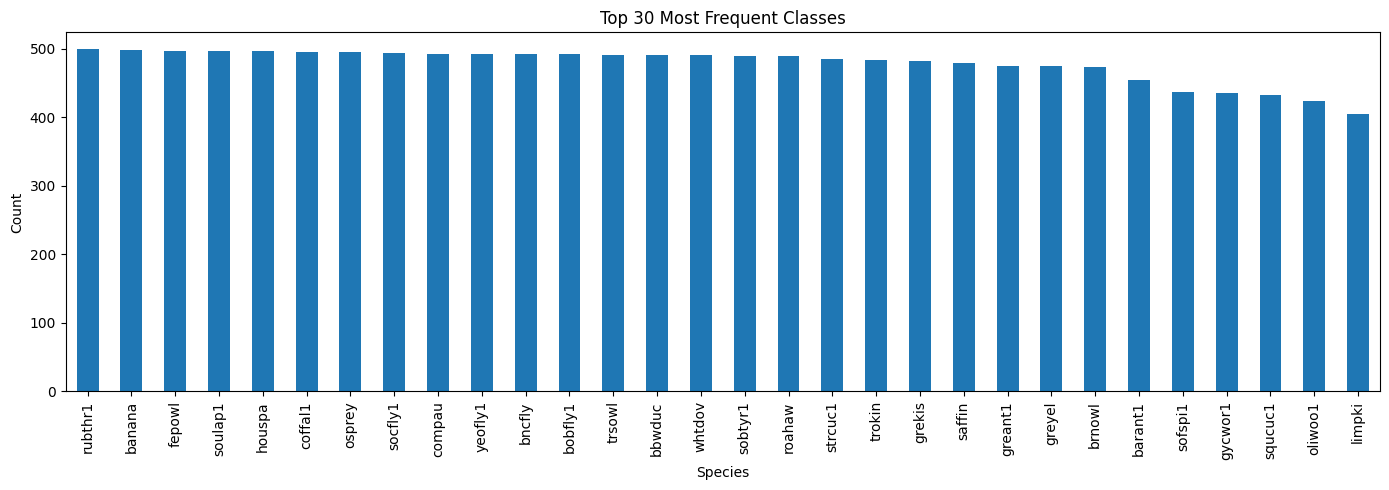

In [15]:
plt.figure(figsize=(14,5))
train_df["primary_label"].value_counts().head(30).plot(kind="bar")
plt.title("Top 30 Most Frequent Classes")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

###Distribution

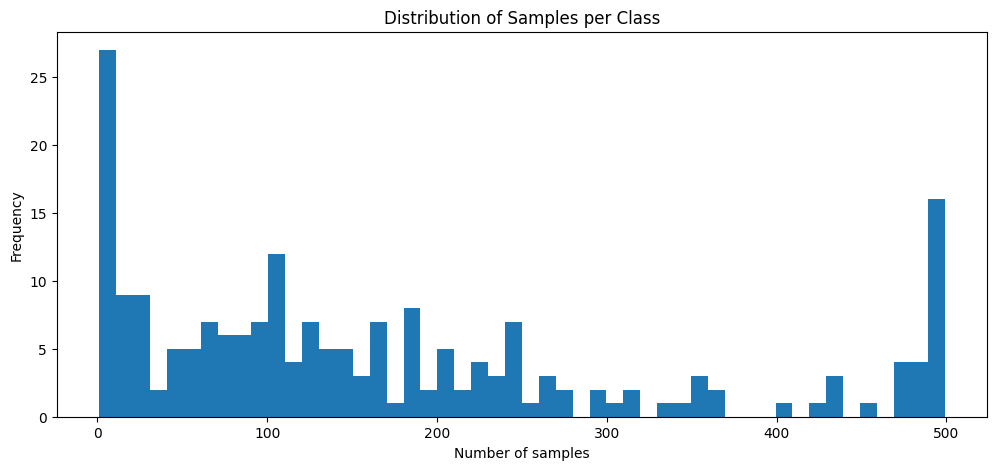

In [16]:
plt.figure(figsize=(12,5))
train_df["primary_label"].value_counts().plot(kind="hist", bins=50)
plt.title("Distribution of Samples per Class")
plt.xlabel("Number of samples")
plt.ylabel("Frequency")
plt.show()

In [17]:
train_df["collection"].value_counts(dropna=False)

,count
collection,
XC,23043
iNat,12506


In [18]:
taxonomy_df["class_name"].value_counts(dropna=False)

,count
class_name,
Aves,162
Amphibia,35
Insecta,28
Mammalia,8
Reptilia,1


###Prepare train_audio metadata

In [19]:
train_df = train_df[train_df["primary_label"].isin(species_cols)].copy()
train_df["filepath"] = train_df["filename"].apply(lambda x: os.path.join(TRAIN_AUDIO_DIR, x))
train_df = train_df[train_df["filepath"].apply(os.path.exists)].reset_index(drop=True)

print("Filtered train_df:", train_df.shape)
train_df.head()

Filtered train_df: (35549, 16)


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection,filepath
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat,/content/drive/MyDrive/BirdCLEF_2026_Team7/dat...
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat,/content/drive/MyDrive/BirdCLEF_2026_Team7/dat...
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat,/content/drive/MyDrive/BirdCLEF_2026_Team7/dat...
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat,/content/drive/MyDrive/BirdCLEF_2026_Team7/dat...
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat,/content/drive/MyDrive/BirdCLEF_2026_Team7/dat...


###Parse secondary labels

In [20]:
import ast

def parse_secondary_labels(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        parsed = ast.literal_eval(x)
        if isinstance(parsed, list):
            return [s for s in parsed if s in species_cols]
        return []
    except:
        return []

train_df["secondary_labels_parsed"] = train_df["secondary_labels"].apply(parse_secondary_labels)
train_df[["primary_label", "secondary_labels", "secondary_labels_parsed"]].head()

,primary_label,secondary_labels,secondary_labels_parsed
0,1161364,[],[]
1,1161364,[],[]
2,1161364,[],[]
3,1161364,[],[]
4,1161364,[],[]


In [21]:
train_df["secondary_labels_parsed"].apply(len).value_counts().head()

,count
secondary_labels_parsed,
0,31177
1,2623
2,1049
3,379
4,169


In [22]:
train_df[train_df["secondary_labels_parsed"].apply(len) > 0][
    ["primary_label", "secondary_labels", "secondary_labels_parsed"]
].head()

,primary_label,secondary_labels,secondary_labels_parsed
138,22973,['compau'],[compau]
169,23158,['saffin'],[saffin]
239,24279,"['326272', '67107']","[326272, 67107]"
240,24279,"['326272', '67107']","[326272, 67107]"
241,24279,['326272'],[326272]


###Audio utility functions

In [23]:
def load_audio(path, sr=32000, duration=5):
    audio, _ = librosa.load(path, sr=sr, mono=True)
    max_len = sr * duration

    if len(audio) < max_len:
        audio = np.pad(audio, (0, max_len - len(audio)))
    else:
        audio = audio[:max_len]

    return audio.astype(np.float32)

In [24]:
def audio_to_mel(audio, cfg):
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=cfg["sample_rate"],
        n_fft=cfg["n_fft"],
        hop_length=cfg["hop_length"],
        n_mels=cfg["n_mels"],
        fmin=cfg["fmin"],
        fmax=cfg["fmax"]
    )
    mel = librosa.power_to_db(mel, ref=np.max)
    return mel.astype(np.float32)

In [25]:
def normalize_mel(mel):
    mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-6)
    return mel

In [26]:
def apply_specaugment(mel, time_mask_param=20, freq_mask_param=10):
    mel_aug = mel.copy()

    # time mask
    t = mel_aug.shape[1]
    if t > 1:
        t_mask = np.random.randint(0, min(time_mask_param, t))
        t0 = np.random.randint(0, max(1, t - t_mask))
        mel_aug[:, t0:t0+t_mask] = 0.0

    # freq mask
    f = mel_aug.shape[0]
    if f > 1:
        f_mask = np.random.randint(0, min(freq_mask_param, f))
        f0 = np.random.randint(0, max(1, f - f_mask))
        mel_aug[f0:f0+f_mask, :] = 0.0

    return mel_aug

###Sanity check

- Loads real audio
- Converts to spectrogram
- Shows transformations

Audio shape: (160000,)
Audio dtype: float32
Mel shape: (128, 313)
Mel min/max: -80.0 0.0
Normalized mel min/max: 0.0 1.0


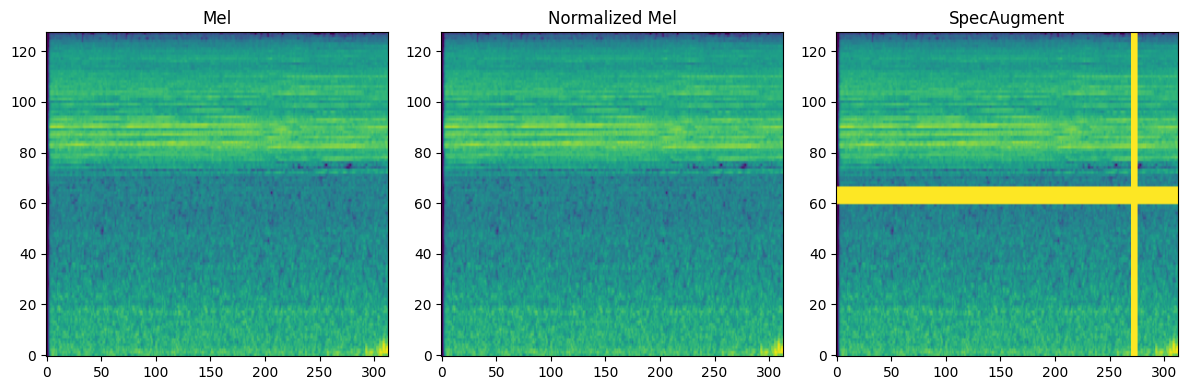

In [27]:
sample_path = train_df["filepath"].iloc[0]

audio = load_audio(sample_path)
print("Audio shape:", audio.shape)
print("Audio dtype:", audio.dtype)

mel = audio_to_mel(audio, CFG)
print("Mel shape:", mel.shape)
print("Mel min/max:", mel.min(), mel.max())

mel_norm = normalize_mel(mel)
print("Normalized mel min/max:", mel_norm.min(), mel_norm.max())

mel_aug = apply_specaugment(mel.copy())

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Mel")
plt.imshow(mel, aspect="auto", origin="lower")

plt.subplot(1,3,2)
plt.title("Normalized Mel")
plt.imshow(mel_norm, aspect="auto", origin="lower")

plt.subplot(1,3,3)
plt.title("SpecAugment")
plt.imshow(mel_aug, aspect="auto", origin="lower")

plt.tight_layout()
plt.show()

###Visualize a spectrogram

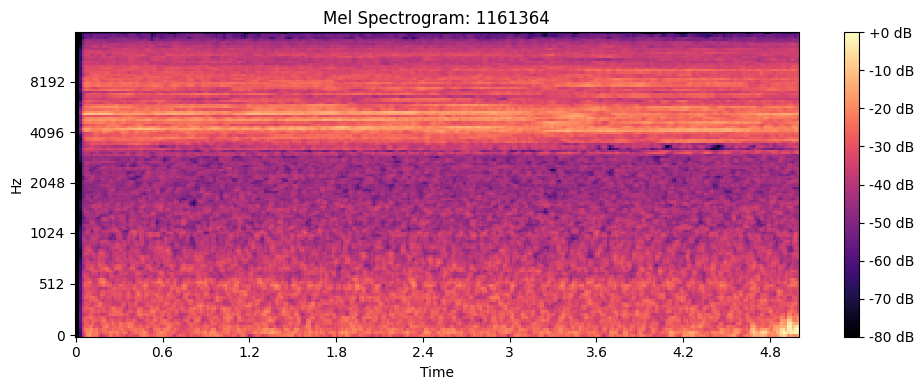

In [28]:
sample_row = train_df.iloc[0]
audio = load_audio(sample_row["filepath"], sr=CFG["sample_rate"], duration=CFG["duration"])
mel = audio_to_mel(audio, CFG)

plt.figure(figsize=(10,4))
librosa.display.specshow(
    mel,
    sr=CFG["sample_rate"],
    hop_length=CFG["hop_length"],
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title(f"Mel Spectrogram: {sample_row['primary_label']}")
plt.tight_layout()
plt.show()

###Train-validation split

In [29]:
label_counts = train_df["primary_label"].value_counts()

train_df_split = train_df[
    train_df["primary_label"].isin(label_counts[label_counts >= 2].index)
].copy()

print("Original train_df:", train_df.shape)
print("Filtered for split:", train_df_split.shape)
print("Min samples per class:", train_df_split["primary_label"].value_counts().min())

Original train_df: (35549, 17)
Filtered for split: (35545, 17)
Min samples per class: 2


In [30]:
train_meta, valid_meta = train_test_split(
    train_df_split,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df_split["primary_label"]
)

train_meta = train_meta.reset_index(drop=True)
valid_meta = valid_meta.reset_index(drop=True)

print("train_meta:", train_meta.shape)
print("valid_meta:", valid_meta.shape)

train_meta: (28436, 17)
valid_meta: (7109, 17)


In [31]:
label_counts = train_df["primary_label"].value_counts()

train_df_split = train_df[
    train_df["primary_label"].isin(label_counts[label_counts >= 2].index)
].copy()

train_meta, valid_meta = train_test_split(
    train_df_split,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df_split["primary_label"]
)

train_meta = train_meta.reset_index(drop=True)
valid_meta = valid_meta.reset_index(drop=True)

print("Full train_meta:", train_meta.shape)
print("Full valid_meta:", valid_meta.shape)

Full train_meta: (28436, 17)
Full valid_meta: (7109, 17)


###Create Dataset

In [32]:
class BirdAudioDataset(Dataset):
    def __init__(self, df, cfg, mode="train"):
        self.df = df
        self.cfg = cfg
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def build_target(self, row):
        target = np.zeros(num_classes, dtype=np.float32)

        primary = row["primary_label"]
        if primary in label_to_idx:
            target[label_to_idx[primary]] = 1.0

        if self.cfg["use_secondary_labels"]:
            for sec in row["secondary_labels_parsed"]:
                if sec in label_to_idx:
                    target[label_to_idx[sec]] = 1.0

        return target

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        audio = load_audio(
            row["filepath"],
            sr=self.cfg["sample_rate"],
            duration=self.cfg["duration"]
        )

        mel = audio_to_mel(audio, self.cfg)

        if self.mode == "train" and self.cfg["use_specaugment"]:
            mel = apply_specaugment(mel)

        mel = normalize_mel(mel)
        mel = cv2.resize(mel, (self.cfg["img_size"], self.cfg["img_size"]))
        mel = mel.astype(np.float32)
        mel = np.stack([mel, mel, mel], axis=0)

        target = self.build_target(row)

        return torch.tensor(mel, dtype=torch.float32), torch.tensor(target, dtype=torch.float32)

###Create DataLoaders

In [33]:
train_dataset = BirdAudioDataset(train_meta, CFG, mode="train")
valid_dataset = BirdAudioDataset(valid_meta, CFG, mode="valid")

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))

Train batches: 889
Valid batches: 223


In [34]:
images, targets = next(iter(train_loader))
print("Images shape:", images.shape)
print("Targets shape:", targets.shape)
print("Images dtype:", images.dtype)
print("Targets dtype:", targets.dtype)

Images shape: torch.Size([32, 3, 224, 224])
Targets shape: torch.Size([32, 234])
Images dtype: torch.float32
Targets dtype: torch.float32


###Model

In [35]:
class BirdCLEFModel(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=num_classes
        )

    def forward(self, x):
        return self.backbone(x)

model = BirdCLEFModel(CFG["model_name"], num_classes).to(device)
model

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

BirdCLEFModel(
  (backbone): EfficientNet(
    (conv_stem): Conv2dSame(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Conv2d(32, 

###Loss and optimizer

In [36]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG["epochs"]
)

###Validation metric

In [37]:
def macro_roc_auc_skip_empty(y_true, y_pred):
    aucs = []
    for c in range(y_true.shape[1]):
        if np.sum(y_true[:, c]) > 0 and np.sum(y_true[:, c]) < len(y_true):
            try:
                auc = roc_auc_score(y_true[:, c], y_pred[:, c])
                aucs.append(auc)
            except:
                pass
    if len(aucs) == 0:
        return np.nan
    return float(np.mean(aucs))

##Part1 - Training Baseline Model with Full FT

###Train / valid loops

In [38]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for images, targets in tqdm(loader):
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)

In [39]:
def valid_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    preds_all = []
    targets_all = []

    with torch.no_grad():
        for images, targets in tqdm(loader):
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)
            loss = criterion(logits, targets)

            probs = torch.sigmoid(logits)

            running_loss += loss.item() * images.size(0)
            preds_all.append(probs.cpu().numpy())
            targets_all.append(targets.cpu().numpy())

    val_loss = running_loss / len(loader.dataset)
    preds_all = np.concatenate(preds_all, axis=0)
    targets_all = np.concatenate(targets_all, axis=0)

    val_auc = macro_roc_auc_skip_empty(targets_all, preds_all)

    return val_loss, val_auc, preds_all, targets_all

###Train baseline model - don't run (Model already saved in drive)

In [ ]:
history = []
best_auc = -1

checkpoint_path = f"{DIRS['checkpoints']}/baseline_effb2_primary_secondary.pth"

for epoch in range(CFG["epochs"]):
    print(f"\nEpoch {epoch+1}/{CFG['epochs']}")

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_auc, val_preds, val_targets = valid_one_epoch(model, valid_loader, criterion, device)

    scheduler.step()

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val AUC:    {val_auc:.4f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_auc": val_auc
    })

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), checkpoint_path)
        print("Saved best model.")


Epoch 1/10


100%|██████████| 223/223 [09:28<00:00,  2.55s/it]


Train Loss: 0.0307
Val Loss:   0.0223
Val AUC:    0.8722
Saved best model.

Epoch 2/10


100%|██████████| 223/223 [09:01<00:00,  2.43s/it]


Train Loss: 0.0191
Val Loss:   0.0163
Val AUC:    0.9333
Saved best model.

Epoch 3/10


...

Train Loss: 0.0043
Val Loss:   0.0132
Val AUC:    0.9566

Epoch 9/10


100%|██████████| 223/223 [09:03<00:00,  2.44s/it]


Train Loss: 0.0031
Val Loss:   0.0137
Val AUC:    0.9526

Epoch 10/10


100%|██████████| 223/223 [09:03<00:00,  2.44s/it]


Train Loss: 0.0025
Val Loss:   0.0136
Val AUC:    0.9537


In [40]:
baseline_best_auc = 0.9575800895062778

###Save logs and config

In [ ]:
history_df = pd.DataFrame(history)
history_df.to_csv(f"{DIRS['logs']}/baseline_history.csv", index=False)
history_df

,epoch,train_loss,val_loss,val_auc
0,1,0.030705,0.022307,0.872244
1,2,0.019076,0.016314,0.933302
2,3,0.015004,0.014561,0.948576
3,4,0.012509,0.013667,0.951156
4,5,0.010335,0.012958,0.955587
5,6,0.008210,0.012796,0.957580
6,7,0.006078,0.012956,0.953586
7,8,0.004343,0.013174,0.956620
8,9,0.003144,0.013702,0.952630
9,10,0.002537,0.013574,0.953715


In [39]:
with open(f"{DIRS['exports']}/config.json", "w") as f:
    json.dump(CFG, f, indent=2)

with open(f"{DIRS['exports']}/label_map.json", "w") as f:
    json.dump(label_to_idx, f, indent=2)

print("Saved config and label mapping.")

Saved config and label mapping.


###Plot training curves

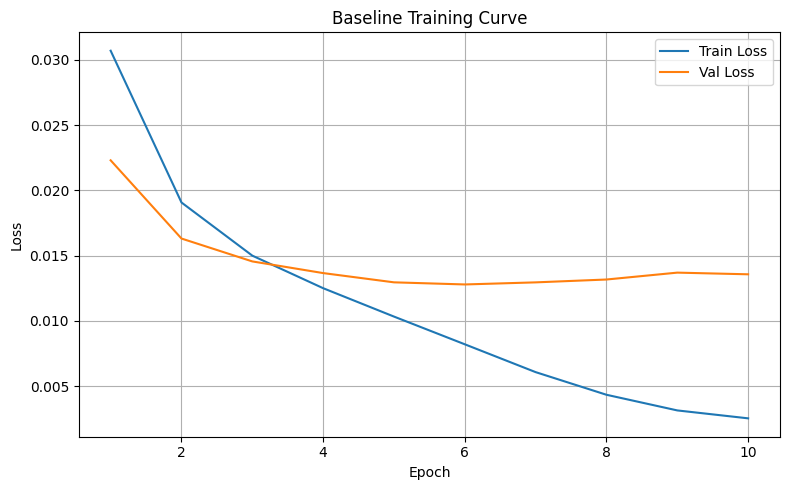

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Training Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

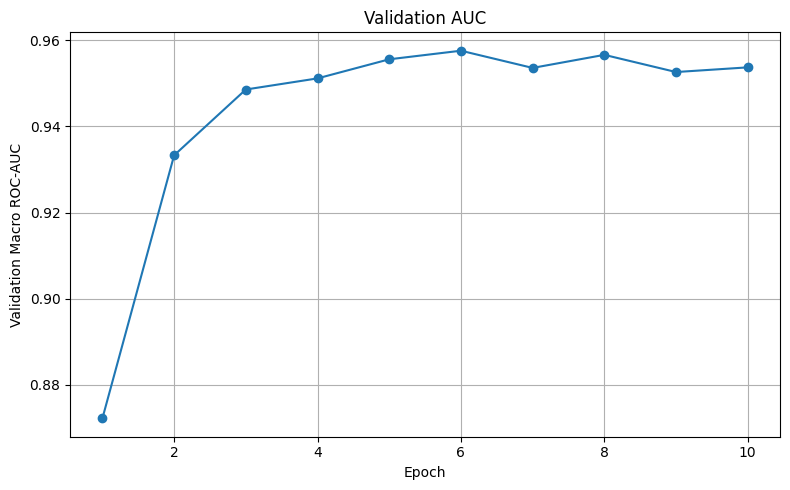

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_df["epoch"], history_df["val_auc"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Macro ROC-AUC")
plt.title("Validation AUC")
plt.grid(True)
plt.tight_layout()
plt.show()

##Part2 - Improvements

###Part 2A - Weighted BCE

###Compute class weights

In [41]:
primary_counts = train_meta["primary_label"].value_counts().to_dict()

pos_weight = np.ones(num_classes, dtype=np.float32)

max_count = max(primary_counts.values())

for label, idx in label_to_idx.items():
    count = primary_counts.get(label, 1)


    pos_weight[idx] = max_count / count


pos_weight = np.clip(pos_weight, 1.0, 10.0)

pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(device)

weighted_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

print("Weighted BCE ready.")
print("Min weight:", pos_weight.min())
print("Max weight:", pos_weight.max())
print("Mean weight:", pos_weight.mean())

Weighted BCE ready.
Min weight: 1.0
Max weight: 10.0
Mean weight: 5.6173353


###Reinitialize model

In [44]:
CFG["epochs"] = 3
print("Weighted BCE experiment epochs:", CFG["epochs"])

Weighted BCE experiment epochs: 3


In [45]:
weighted_model = BirdCLEFModel(CFG["model_name"], num_classes).to(device)

weighted_optimizer = optim.AdamW(
    weighted_model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)

weighted_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    weighted_optimizer,
    T_max=CFG["epochs"]
)

print("Weighted BCE model reset for 3-epoch experiment.")

Weighted BCE model reset for 3-epoch experiment.


###Train Weighted BCE model

In [46]:
weighted_history = []
weighted_best_auc = -1

weighted_checkpoint_path = f"{DIRS['checkpoints']}/effb2_weighted_bce_3epochs.pth"

for epoch in range(CFG["epochs"]):
    print(f"\n[Weighted BCE] Epoch {epoch+1}/{CFG['epochs']}")

    train_loss = train_one_epoch(
        weighted_model,
        train_loader,
        weighted_optimizer,
        weighted_criterion,
        device
    )

    val_loss, val_auc, val_preds, val_targets = valid_one_epoch(
        weighted_model,
        valid_loader,
        weighted_criterion,
        device
    )

    weighted_scheduler.step()

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val AUC:    {val_auc:.4f}")

    weighted_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_auc": val_auc
    })

    if val_auc > weighted_best_auc:
        weighted_best_auc = val_auc
        torch.save(weighted_model.state_dict(), weighted_checkpoint_path)
        print("Saved best weighted BCE model.")

print("Best Weighted BCE AUC:", weighted_best_auc)


[Weighted BCE] Epoch 1/3


100%|██████████| 223/223 [56:58<00:00, 15.33s/it]


Train Loss: 0.0591
Val Loss:   0.0443
Val AUC:    0.8916
Saved best weighted BCE model.

[Weighted BCE] Epoch 2/3


100%|██████████| 223/223 [08:32<00:00,  2.30s/it]


Train Loss: 0.0367
Val Loss:   0.0333
Val AUC:    0.9373
Saved best weighted BCE model.

[Weighted BCE] Epoch 3/3


100%|██████████| 223/223 [08:34<00:00,  2.31s/it]


Train Loss: 0.0259
Val Loss:   0.0270
Val AUC:    0.9539
Saved best weighted BCE model.
Best Weighted BCE AUC: 0.9538747101570428


###Prepare continuation to 6 epochs

In [47]:
CFG["epochs"] = 6

weighted_best_auc = max([x["val_auc"] for x in weighted_history])

weighted_checkpoint_path = f"{DIRS['checkpoints']}/effb2_weighted_bce_6epochs.pth"

print("Continuing Weighted BCE training")
print("Current best AUC:", weighted_best_auc)
print("Saving best model to:", weighted_checkpoint_path)

Continuing Weighted BCE training
Current best AUC: 0.9538747101570428
Saving best model to: /content/drive/MyDrive/BirdCLEF_2026_Team7/checkpoints/effb2_weighted_bce_6epochs.pth


###Continue training epochs 4 to 6

In [48]:
for epoch in range(3, 6):
    print(f"\n[Weighted BCE] Epoch {epoch+1}/6")

    train_loss = train_one_epoch(
        weighted_model,
        train_loader,
        weighted_optimizer,
        weighted_criterion,
        device
    )

    val_loss, val_auc, val_preds, val_targets = valid_one_epoch(
        weighted_model,
        valid_loader,
        weighted_criterion,
        device
    )

    weighted_scheduler.step()

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val AUC:    {val_auc:.4f}")

    weighted_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_auc": val_auc
    })

    if val_auc > weighted_best_auc:
        weighted_best_auc = val_auc
        torch.save(weighted_model.state_dict(), weighted_checkpoint_path)
        print("Saved best weighted BCE model.")

print("Best Weighted BCE AUC:", weighted_best_auc)


[Weighted BCE] Epoch 4/6


100%|██████████| 223/223 [08:32<00:00,  2.30s/it]


Train Loss: 0.0218
Val Loss:   0.0270
Val AUC:    0.9537

[Weighted BCE] Epoch 5/6


100%|██████████| 223/223 [08:34<00:00,  2.31s/it]


Train Loss: 0.0217
Val Loss:   0.0263
Val AUC:    0.9559
Saved best weighted BCE model.

[Weighted BCE] Epoch 6/6


100%|██████████| 223/223 [08:34<00:00,  2.31s/it]


Train Loss: 0.0243
Val Loss:   0.0287
Val AUC:    0.9484
Best Weighted BCE AUC: 0.9559458995806781


###Save Weighted BCE logs

In [49]:
weighted_history_df = pd.DataFrame(weighted_history)
weighted_history_df.to_csv(f"{DIRS['logs']}/weighted_bce_history_6epochs.csv", index=False)
weighted_history_df

,epoch,train_loss,val_loss,val_auc
0,1,0.059100,0.044270,0.891597
1,2,0.036723,0.033267,0.937327
2,3,0.025876,0.027032,0.953875
3,4,0.021752,0.026953,0.953671
4,5,0.021704,0.026275,0.955946
5,6,0.024318,0.028682,0.948434


###Compare Baseline vs Weighted BCE

In [50]:
baseline_best_auc = 0.9575800895062778

In [51]:
comparison_df = pd.DataFrame([
    {
        "experiment": "E1",
        "model": "EfficientNet-B2",
        "data": "train_audio",
        "loss": "BCEWithLogitsLoss",
        "epochs_run": 10,
        "best_epoch": 6,
        "best_val_auc": baseline_best_auc,
        "notes": "Baseline full fine-tuning; best checkpoint occurred before final epoch"
    },
    {
        "experiment": "E2",
        "model": "EfficientNet-B2",
        "data": "train_audio",
        "loss": "Weighted BCEWithLogitsLoss",
        "epochs_run": 6,
        "best_epoch": 5,
        "best_val_auc": weighted_best_auc,
        "notes": "Class imbalance handling using positive class weights"
    }
])

comparison_df.to_csv(f"{DIRS['logs']}/experiment_tracking.csv", index=False)
comparison_df

,experiment,model,data,loss,epochs_run,best_epoch,best_val_auc,notes
0,E1,EfficientNet-B2,train_audio,BCEWithLogitsLoss,10,6,0.957580,Baseline full fine-tuning; best checkpoint occ...
1,E2,EfficientNet-B2,train_audio,Weighted BCEWithLogitsLoss,6,5,0.955946,Class imbalance handling using positive class ...


###Part 2B - Soundscape Fine-Tuning

In [42]:
print(soundscape_labels_df.shape)
print(soundscape_labels_df.columns.tolist())
soundscape_labels_df.head()

(1478, 4)
['filename', 'start', 'end', 'primary_label']


,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380


In [43]:
print(os.listdir(TRAIN_SOUNDSCAPES_DIR)[:5])

['BC2026_Train_9000_S22_20230221_011500.ogg', 'BC2026_Train_9001_S22_20230221_201500.ogg', 'BC2026_Train_9002_S22_20230221_210000.ogg', 'BC2026_Train_9003_S22_20230221_211500.ogg', 'BC2026_Train_9004_S22_20230221_221500.ogg']


###Prepare soundscape metadata

In [44]:
from sklearn.model_selection import GroupShuffleSplit

def time_to_seconds(t):
    parts = str(t).split(":")
    return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])

def parse_soundscape_labels(x):
    if pd.isna(x):
        return []
    return [s.strip() for s in str(x).split(";") if s.strip() in label_to_idx]

soundscape_df = soundscape_labels_df.copy()

soundscape_df["start_sec"] = soundscape_df["start"].apply(time_to_seconds)
soundscape_df["end_sec"] = soundscape_df["end"].apply(time_to_seconds)
soundscape_df["duration_sec"] = soundscape_df["end_sec"] - soundscape_df["start_sec"]

soundscape_df["labels_list"] = soundscape_df["primary_label"].apply(parse_soundscape_labels)
soundscape_df["filepath"] = soundscape_df["filename"].apply(
    lambda x: os.path.join(TRAIN_SOUNDSCAPES_DIR, x)
)

soundscape_df = soundscape_df[
    (soundscape_df["filepath"].apply(os.path.exists)) &
    (soundscape_df["labels_list"].apply(len) > 0)
].reset_index(drop=True)

print("Soundscape rows:", soundscape_df.shape)
soundscape_df.head()

Soundscape rows: (1478, 9)


,filename,start,end,primary_label,start_sec,end_sec,duration_sec,labels_list,filepath
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380,0,5,5,"[22961, 23158, 24321, 517063, 65380]",/content/drive/MyDrive/BirdCLEF_2026_Team7/dat...
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380,5,10,5,"[22961, 23158, 24321, 517063, 65380]",/content/drive/MyDrive/BirdCLEF_2026_Team7/dat...
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380,10,15,5,"[22961, 23158, 24321, 517063, 65380]",/content/drive/MyDrive/BirdCLEF_2026_Team7/dat...
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380,15,20,5,"[22961, 23158, 24321, 517063, 65380]",/content/drive/MyDrive/BirdCLEF_2026_Team7/dat...
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380,20,25,5,"[22961, 23158, 24321, 517063, 65380]",/content/drive/MyDrive/BirdCLEF_2026_Team7/dat...


###Group split by soundscape file

In [45]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)

train_idx, valid_idx = next(
    gss.split(soundscape_df, groups=soundscape_df["filename"])
)

sound_train_meta = soundscape_df.iloc[train_idx].reset_index(drop=True)
sound_valid_meta = soundscape_df.iloc[valid_idx].reset_index(drop=True)

print("Sound train:", sound_train_meta.shape)
print("Sound valid:", sound_valid_meta.shape)
print("Train files:", sound_train_meta["filename"].nunique())
print("Valid files:", sound_valid_meta["filename"].nunique())

Sound train: (1182, 9)
Sound valid: (296, 9)
Train files: 52
Valid files: 14


###Soundscape Dataset

In [46]:
class SoundscapeSegmentDataset(Dataset):
    def __init__(self, df, cfg, mode="train"):
        self.df = df
        self.cfg = cfg
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def build_target(self, labels):
        target = np.zeros(num_classes, dtype=np.float32)
        for lb in labels:
            if lb in label_to_idx:
                target[label_to_idx[lb]] = 1.0
        return target

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        audio, _ = librosa.load(
            row["filepath"],
            sr=self.cfg["sample_rate"],
            mono=True,
            offset=float(row["start_sec"]),
            duration=float(row["duration_sec"])
        )

        max_len = self.cfg["samples"]

        if len(audio) < max_len:
            audio = np.pad(audio, (0, max_len - len(audio)))
        else:
            audio = audio[:max_len]

        audio = audio.astype(np.float32)

        mel = audio_to_mel(audio, self.cfg)

        if self.mode == "train" and self.cfg["use_specaugment"]:
            mel = apply_specaugment(mel)

        mel = normalize_mel(mel)
        mel = cv2.resize(mel, (self.cfg["img_size"], self.cfg["img_size"]))
        mel = mel.astype(np.float32)
        mel = np.stack([mel, mel, mel], axis=0)

        target = self.build_target(row["labels_list"])

        return torch.tensor(mel, dtype=torch.float32), torch.tensor(target, dtype=torch.float32)

###Create soundscape dataloaders

In [47]:
sound_train_dataset = SoundscapeSegmentDataset(sound_train_meta, CFG, mode="train")
sound_valid_dataset = SoundscapeSegmentDataset(sound_valid_meta, CFG, mode="valid")

sound_train_loader = DataLoader(
    sound_train_dataset,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=True
)

sound_valid_loader = DataLoader(
    sound_valid_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True
)

print("Sound train batches:", len(sound_train_loader))
print("Sound valid batches:", len(sound_valid_loader))

Sound train batches: 37
Sound valid batches: 10


###Batch sanity check

In [48]:
x, y = next(iter(sound_train_loader))

print("Input shape:", x.shape)
print("Target shape:", y.shape)
print("Input dtype:", x.dtype)
print("Target dtype:", y.dtype)
print("Target positives in batch:", y.sum().item())

Input shape: torch.Size([32, 3, 224, 224])
Target shape: torch.Size([32, 234])
Input dtype: torch.float32
Target dtype: torch.float32
Target positives in batch: 124.0


###Load Baseline Checkpoint

In [46]:
sound_model = BirdCLEFModel(CFG["model_name"], num_classes).to(device)

baseline_ckpt = f"{DIRS['checkpoints']}/baseline_effb2_primary_secondary.pth"

sound_model.load_state_dict(torch.load(baseline_ckpt, map_location=device))

print("Loaded baseline checkpoint for soundscape fine-tuning.")

Loaded baseline checkpoint for soundscape fine-tuning.


###Optimizer / Scheduler

In [47]:
CFG["epochs"] = 6

sound_optimizer = optim.AdamW(
    sound_model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

sound_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    sound_optimizer,
    T_max=CFG["epochs"]
)

sound_criterion = nn.BCEWithLogitsLoss()

print("Soundscape fine-tuning setup ready.")

Soundscape fine-tuning setup ready.


###Training Loop

In [48]:
sound_history = []
sound_best_auc = -1

sound_ckpt_path = f"{DIRS['checkpoints']}/effb2_soundscape_finetuned.pth"

for epoch in range(CFG["epochs"]):
    print(f"\n[Soundscape FT] Epoch {epoch+1}/{CFG['epochs']}")

    train_loss = train_one_epoch(
        sound_model,
        sound_train_loader,
        sound_optimizer,
        sound_criterion,
        device
    )

    val_loss, val_auc, _, _ = valid_one_epoch(
        sound_model,
        sound_valid_loader,
        sound_criterion,
        device
    )

    sound_scheduler.step()

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val AUC:    {val_auc:.4f}")

    sound_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_auc": val_auc
    })

    if val_auc > sound_best_auc:
        sound_best_auc = val_auc
        torch.save(sound_model.state_dict(), sound_ckpt_path)
        print("Saved best soundscape model.")

print("Best Soundscape AUC:", sound_best_auc)


[Soundscape FT] Epoch 1/6


100%|██████████| 10/10 [00:38<00:00,  3.84s/it]


Train Loss: 0.0736
Val Loss:   0.0683
Val AUC:    0.7969
Saved best soundscape model.

[Soundscape FT] Epoch 2/6


100%|██████████| 10/10 [00:14<00:00,  1.48s/it]


Train Loss: 0.0225
Val Loss:   0.0589
Val AUC:    0.8321
Saved best soundscape model.

[Soundscape FT] Epoch 3/6


...

Train Loss: 0.0098
Val Loss:   0.0603
Val AUC:    0.8381
Saved best soundscape model.

[Soundscape FT] Epoch 5/6


100%|██████████| 10/10 [00:14<00:00,  1.49s/it]


Train Loss: 0.0080
Val Loss:   0.0611
Val AUC:    0.8417
Saved best soundscape model.

[Soundscape FT] Epoch 6/6


100%|██████████| 10/10 [00:14<00:00,  1.47s/it]


Train Loss: 0.0072
Val Loss:   0.0611
Val AUC:    0.8428
Saved best soundscape model.
Best Soundscape AUC: 0.8428220239191065


###Baseline-on-Soundscape Evaluation Cell

In [49]:
baseline_sound_eval_model = BirdCLEFModel(
    CFG["model_name"],
    num_classes
).to(device)

baseline_ckpt = f"{DIRS['checkpoints']}/baseline_effb2_primary_secondary.pth"
baseline_sound_eval_model.load_state_dict(
    torch.load(baseline_ckpt, map_location=device)
)

baseline_sound_eval_model.eval()


baseline_sound_val_loss, baseline_sound_val_auc, _, _ = valid_one_epoch(
    baseline_sound_eval_model,
    sound_valid_loader,
    nn.BCEWithLogitsLoss(),
    device
)

print("Baseline on Soundscape Validation")
print("Val Loss:", round(baseline_sound_val_loss, 4))
print("Val AUC :", round(baseline_sound_val_auc, 4))

100%|██████████| 10/10 [00:14<00:00,  1.45s/it]

Baseline on Soundscape Validation
Val Loss: 0.1583
Val AUC : 0.6487


###Save soundscape history

In [50]:
sound_history_df = pd.DataFrame(sound_history)
sound_history_df.to_csv(f"{DIRS['logs']}/soundscape_finetune_history_6epochs.csv", index=False)
sound_history_df

,epoch,train_loss,val_loss,val_auc
0,1,0.073632,0.068317,0.796940
1,2,0.022523,0.058932,0.832130
2,3,0.013513,0.059695,0.832415
3,4,0.009836,0.060288,0.838148
4,5,0.008011,0.061084,0.841666
5,6,0.007158,0.061129,0.842822


###Add soundscape results to experiment table

In [49]:
baseline_best_auc = 0.9576
weighted_best_auc = 0.9559
baseline_soundscape_auc = 0.6487
soundscape_best_auc = 0.8428

In [56]:
soundscape_best_auc = sound_best_auc
baseline_soundscape_auc = baseline_sound_val_auc

comparison_df = pd.DataFrame([
    {
        "experiment": "E1",
        "model": "EfficientNet-B2",
        "data": "train_audio",
        "loss": "BCEWithLogitsLoss",
        "epochs_run": 10,
        "best_epoch": 6,
        "best_val_auc": baseline_best_auc,
        "validation_set": "clean train_audio validation",
        "notes": "Baseline full fine-tuning"
    },
    {
        "experiment": "E2",
        "model": "EfficientNet-B2",
        "data": "train_audio",
        "loss": "Weighted BCEWithLogitsLoss",
        "epochs_run": 6,
        "best_epoch": 5,
        "best_val_auc": weighted_best_auc,
        "validation_set": "clean train_audio validation",
        "notes": "Class imbalance handling using positive class weights"
    },
    {
        "experiment": "E3",
        "model": "EfficientNet-B2",
        "data": "train_audio checkpoint",
        "loss": "BCEWithLogitsLoss",
        "epochs_run": 0,
        "best_epoch": None,
        "best_val_auc": baseline_soundscape_auc,
        "validation_set": "soundscape validation",
        "notes": "Baseline checkpoint evaluated on soundscape data without fine-tuning"
    },
    {
        "experiment": "E4",
        "model": "EfficientNet-B2",
        "data": "train_soundscapes",
        "loss": "BCEWithLogitsLoss",
        "epochs_run": 6,
        "best_epoch": 6,
        "best_val_auc": soundscape_best_auc,
        "validation_set": "soundscape validation",
        "notes": "Domain adaptation using soundscape fine-tuning"
    }
])

comparison_df.to_csv(f"{DIRS['logs']}/experiment_tracking.csv", index=False)
comparison_df

,experiment,model,data,loss,epochs_run,best_epoch,best_val_auc,validation_set,notes
0,E1,EfficientNet-B2,train_audio,BCEWithLogitsLoss,10,6.0,0.957600,clean train_audio validation,Baseline full fine-tuning
1,E2,EfficientNet-B2,train_audio,Weighted BCEWithLogitsLoss,6,5.0,0.955900,clean train_audio validation,Class imbalance handling using positive class ...
2,E3,EfficientNet-B2,train_audio checkpoint,BCEWithLogitsLoss,0,NaN,0.648702,soundscape validation,Baseline checkpoint evaluated on soundscape da...
3,E4,EfficientNet-B2,train_soundscapes,BCEWithLogitsLoss,6,6.0,0.842822,soundscape validation,Domain adaptation using soundscape fine-tuning


### Final Inference Demo on Soundscape Validation Data

Since Kaggle hidden test data is not available outside Kaggle,  
we demonstrate inference using soundscape validation segments from `train_soundscapes`.

Model used: **E4 Soundscape Fine-Tuned EfficientNet-B2**

###Load Best Model

In [50]:
E4_CKPT_PATH = f"{DIRS['checkpoints']}/effb2_soundscape_finetuned.pth"

demo_model = BirdCLEFModel(CFG["model_name"], num_classes).to(device)
demo_model.load_state_dict(torch.load(E4_CKPT_PATH, map_location=device))
demo_model.eval()

print("Loaded model from:", E4_CKPT_PATH)

Loaded model from: /content/drive/MyDrive/BirdCLEF_2026_Team7/checkpoints/effb2_soundscape_finetuned.pth


###Select a Validation Sample

In [51]:
demo_idx = 0

demo_row = sound_valid_meta.iloc[demo_idx]

print("Filename:", demo_row["filename"])
print("Start:", demo_row["start_sec"])
print("Duration:", demo_row["duration_sec"])
print("True labels:", demo_row["labels_list"])

Filename: BC2026_Train_0014_S13_20220228_214500.ogg
Start: 0
Duration: 5
True labels: ['22961', '23158', '65377', '65380']


###Load Audio Segment

In [52]:
from IPython.display import Audio, display

audio, sr = librosa.load(
    demo_row["filepath"],
    sr=CFG["sample_rate"],
    mono=True,
    offset=float(demo_row["start_sec"]),
    duration=float(demo_row["duration_sec"])
)

max_len = CFG["samples"]
if len(audio) < max_len:
    audio = np.pad(audio, (0, max_len - len(audio)))
else:
    audio = audio[:max_len]

audio = audio.astype(np.float32)

print("Audio shape:", audio.shape)

display(Audio(audio, rate=sr))

Audio shape: (160000,)


###Convert to Mel Spectrogram + Visualize

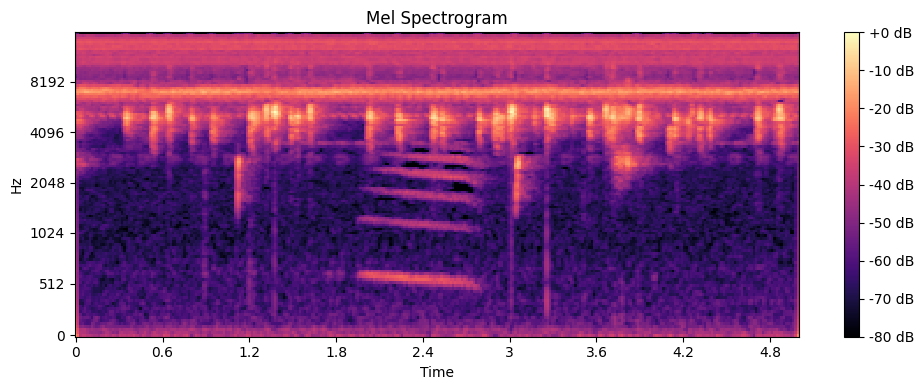

In [53]:
mel = audio_to_mel(audio, CFG)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mel,
    sr=CFG["sample_rate"],
    hop_length=CFG["hop_length"],
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()

###Preprocess for Model

In [54]:
mel_norm = normalize_mel(mel)
mel_resized = cv2.resize(mel_norm, (CFG["img_size"], CFG["img_size"]))

image = np.stack([mel_resized, mel_resized, mel_resized], axis=0).astype(np.float32)

x = torch.tensor(image).unsqueeze(0).to(device)

print("Model input shape:", x.shape)

Model input shape: torch.Size([1, 3, 224, 224])


###Run Inference

In [55]:
with torch.no_grad():
    logits = demo_model(x)
    probs = torch.sigmoid(logits).cpu().numpy()[0]

###Show Top Predictions

In [56]:
top_k = 10
top_indices = np.argsort(probs)[::-1][:top_k]

pred_df = pd.DataFrame({
    "rank": range(1, top_k + 1),
    "species": [idx_to_label[i] for i in top_indices],
    "probability": [probs[i] for i in top_indices]
})

display(pred_df)

print("True labels:", demo_row["labels_list"])

,rank,species,probability
0,1,65380,0.906181
1,2,517063,0.373404
2,3,23158,0.235624
3,4,22973,0.082190
4,5,24321,0.046231
5,6,fotfly,0.021634
6,7,trsowl,0.013657
7,8,47144,0.010445
8,9,555146,0.010237
9,10,66971,0.009724


True labels: ['22961', '23158', '65377', '65380']


In [57]:
for i in range(20):
    labels = sound_valid_meta.iloc[i]["labels_list"]
    if 2 <= len(labels) <= 5:
        print(i, labels)

0 ['22961', '23158', '65377', '65380']
1 ['22961', '23158', '65380']
2 ['22961', '65377', '65380']
3 ['22961', '65377', '65380']
4 ['22961', '23158', '65377', '65380']
5 ['22961', '65377', '65380']
6 ['22961', '65377', '65380']
7 ['22961', '23158', '65380']
8 ['22961', '23158', '517063', '65377', '65380']
9 ['22961', '65380']
10 ['22961', '23158', '65377', '65380']
11 ['22961', '517063', '65377', '65380']
12 ['22961', '23158', '65377', '65380']
13 ['22961', '23158', '65380']
14 ['22961', '65377', '65380']
15 ['22961', '65377', '65380']
16 ['22961', '23158', '65377', '65380']
17 ['22961', '65377', '65380']
18 ['22961', '65377', '65380']
19 ['22961', '23158', '65380']


###Second sample

In [65]:
demo_idx = 24

demo_row = sound_valid_meta.iloc[demo_idx]

print("Filename:", demo_row["filename"])
print("Start:", demo_row["start_sec"])
print("Duration:", demo_row["duration_sec"])
print("True labels:", demo_row["labels_list"])

Filename: BC2026_Train_0046_S22_20220127_230000.ogg
Start: 0
Duration: 5
True labels: ['24279', '555146', '65380', '66971']


In [66]:
from IPython.display import Audio, display

audio, sr = librosa.load(
    demo_row["filepath"],
    sr=CFG["sample_rate"],
    mono=True,
    offset=float(demo_row["start_sec"]),
    duration=float(demo_row["duration_sec"])
)

max_len = CFG["samples"]
if len(audio) < max_len:
    audio = np.pad(audio, (0, max_len - len(audio)))
else:
    audio = audio[:max_len]

audio = audio.astype(np.float32)

print("Audio shape:", audio.shape)

display(Audio(audio, rate=sr))

Audio shape: (160000,)


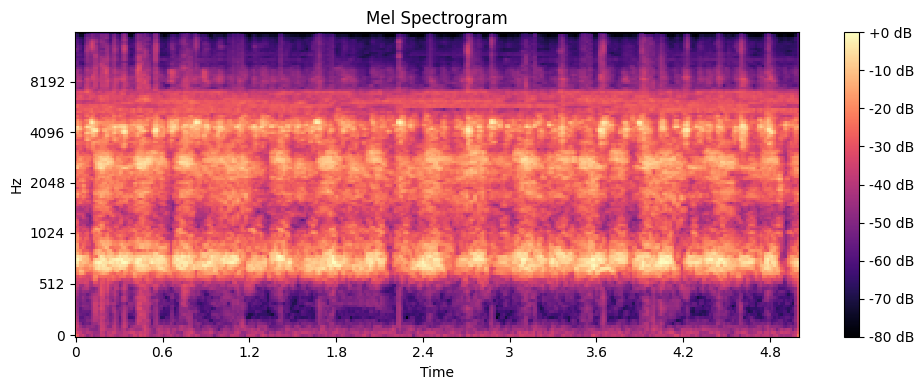

In [67]:
mel = audio_to_mel(audio, CFG)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mel,
    sr=CFG["sample_rate"],
    hop_length=CFG["hop_length"],
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()

In [68]:
mel_norm = normalize_mel(mel)
mel_resized = cv2.resize(mel_norm, (CFG["img_size"], CFG["img_size"]))

image = np.stack([mel_resized, mel_resized, mel_resized], axis=0).astype(np.float32)

x = torch.tensor(image).unsqueeze(0).to(device)

print("Model input shape:", x.shape)

Model input shape: torch.Size([1, 3, 224, 224])


In [69]:
with torch.no_grad():
    logits = demo_model(x)
    probs = torch.sigmoid(logits).cpu().numpy()[0]

In [70]:
top_k = 10
top_indices = np.argsort(probs)[::-1][:top_k]

pred_df = pd.DataFrame({
    "rank": range(1, top_k + 1),
    "species": [idx_to_label[i] for i in top_indices],
    "probability": [probs[i] for i in top_indices]
})

display(pred_df)

print("True labels:", demo_row["labels_list"])

,rank,species,probability
0,1,65380,0.985859
1,2,555146,0.973111
2,3,24321,0.903461
3,4,66971,0.829795
4,5,517063,0.125931
5,6,24279,0.058529
6,7,undtin1,0.006876
7,8,22973,0.005379
8,9,sibtan2,0.003126
9,10,23158,0.002553


True labels: ['24279', '555146', '65380', '66971']


### for the second sample demo_idx =24 , Even in noisy soundscape segments with dense background activity, the model successfully retrieves all ground-truth species within its top predictions, demonstrating strong robustness to real-world acoustic conditions.

##Kaggle Submission Inference

In [57]:
sample_submission_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)

print(sample_submission_df.shape)
print(sample_submission_df.columns.tolist())
sample_submission_df.head()

(3, 235)
['row_id', '1161364', '116570', '1176823', '1491113', '1595929', '209233', '22930', '22956', '22961', '22967', '22973', '22983', '22985', '23150', '23154', '23158', '23176', '23724', '24279', '24285', '24287', '24321', '244024', '25073', '25092', '25214', '326272', '41970', '43435', '47144', '47158son01', '47158son02', '47158son03', '47158son04', '47158son05', '47158son06', '47158son07', '47158son08', '47158son09', '47158son10', '47158son11', '47158son12', '47158son13', '47158son14', '47158son15', '47158son16', '47158son17', '47158son18', '47158son19', '47158son20', '47158son21', '47158son22', '47158son23', '47158son24', '47158son25', '476521', '516975', '517063', '555123', '555145', '555146', '64898', '65377', '65380', '66971', '67107', '67252', '70711', '738183', '74113', '74580', '760266', 'ashgre1', 'astcra1', 'bafcur1', 'baffal1', 'banana', 'barant1', 'batbel1', 'baymac', 'bbwduc', 'bcwfin2', 'bkcdon', 'bkhpar', 'blchaw1', 'blheag1', 'blttit1', 'bncfly', 'bobfly1', 'brcma

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


In [58]:
print(os.listdir(BASE))

['birdclef-2026.zip', 'recording_location.txt', 'sample_submission.csv', 'taxonomy.csv', 'test_soundscapes', 'train.csv', 'train_audio', 'train_soundscapes', 'train_soundscapes_labels.csv']


###Test dataset

In [59]:
TEST_SOUNDSCAPES_DIR = f"{BASE}/test_soundscapes"

class TestSoundscapeDataset(Dataset):
    def __init__(self, sample_df, test_dir, cfg):
        self.sample_df = sample_df.reset_index(drop=True)
        self.test_dir = test_dir
        self.cfg = cfg

    def __len__(self):
        return len(self.sample_df)

    def __getitem__(self, idx):
        row = self.sample_df.iloc[idx]
        row_id = row["row_id"]

        parts = row_id.split("_")
        end_sec = int(parts[-1])
        start_sec = end_sec - self.cfg["duration"]

        filename = "_".join(parts[:-1]) + ".ogg"
        filepath = os.path.join(self.test_dir, filename)

        audio, _ = librosa.load(
            filepath,
            sr=self.cfg["sample_rate"],
            mono=True,
            offset=start_sec,
            duration=self.cfg["duration"]
        )

        max_len = self.cfg["samples"]
        if len(audio) < max_len:
            audio = np.pad(audio, (0, max_len - len(audio)))
        else:
            audio = audio[:max_len]

        mel = audio_to_mel(audio.astype(np.float32), self.cfg)
        mel = normalize_mel(mel)
        mel = cv2.resize(mel, (self.cfg["img_size"], self.cfg["img_size"]))
        mel = np.stack([mel, mel, mel], axis=0).astype(np.float32)

        return torch.tensor(mel, dtype=torch.float32), row_id

###Test loader

In [60]:
test_dataset = TestSoundscapeDataset(sample_submission_df, TEST_SOUNDSCAPES_DIR, CFG)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True
)

print("Test rows:", len(test_dataset))
print("Test batches:", len(test_loader))

Test rows: 3
Test batches: 1


###Prediction function

In [61]:
def predict_checkpoint(checkpoint_path, output_csv):
    model = BirdCLEFModel(CFG["model_name"], num_classes).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    all_row_ids = []
    all_preds = []

    with torch.no_grad():
        for images, row_ids in tqdm(test_loader):
            images = images.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_preds.append(probs)
            all_row_ids.extend(row_ids)

    all_preds = np.concatenate(all_preds, axis=0)

    submission = pd.DataFrame(all_preds, columns=species_cols)
    submission.insert(0, "row_id", all_row_ids)

    submission = submission[sample_submission_df.columns]
    submission.to_csv(output_csv, index=False)

    print("Saved:", output_csv)
    print("Shape:", submission.shape)
    return submission

In [64]:
print(os.listdir(DIRS['checkpoints']))

['baseline_effb2_primary_secondary.pth', 'effb2_weighted_bce_3epochs.pth', 'effb2_weighted_bce_6epochs.pth', 'effb2_soundscape_finetuned.pth']


###Zip the checkpoints

In [65]:
import shutil

shutil.make_archive(
    "/content/birdclef_checkpoints",
    'zip',
    DIRS['checkpoints']
)

'/content/birdclef_checkpoints.zip'

###Download

In [66]:
from google.colab import files
files.download("/content/birdclef_checkpoints.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Listen to clean audio and soundscape audios

In [67]:
import librosa
from IPython.display import Audio

row = soundscape_df.iloc[0]

audio, sr = librosa.load(
    row["filepath"],
    sr=32000,
    offset=row["start_sec"],
    duration=row["duration_sec"]
)

Audio(audio, rate=sr)

In [69]:
print(filepath)
print(os.path.exists(filepath))

/content/drive/MyDrive/BirdCLEF_2026_Team7/data/train_audio/1161364/1161364/iNat1216197.ogg
False


In [70]:
filepath = os.path.join(TRAIN_AUDIO_DIR, filename)

print(filepath)
print(os.path.exists(filepath))

Audio(filename=filepath)

/content/drive/MyDrive/BirdCLEF_2026_Team7/data/train_audio/1161364/iNat1216197.ogg
True


##Part 4 — AST Experiment

In [41]:
import timm

ast_models = [m for m in timm.list_models() if "ast" in m.lower()]
print(ast_models)
print("Total AST models:", len(ast_models))

['fasternet_l', 'fasternet_m', 'fasternet_s', 'fasternet_t0', 'fasternet_t1', 'fasternet_t2', 'fastvit_ma36', 'fastvit_mci0', 'fastvit_mci1', 'fastvit_mci2', 'fastvit_mci3', 'fastvit_mci4', 'fastvit_s12', 'fastvit_sa12', 'fastvit_sa24', 'fastvit_sa36', 'fastvit_t8', 'fastvit_t12']
Total AST models: 18


In [42]:
from transformers import AutoFeatureExtractor, ASTForAudioClassification

AST_MODEL_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"

feature_extractor = AutoFeatureExtractor.from_pretrained(AST_MODEL_NAME)

print("Loaded AST feature extractor")
print(feature_extractor)

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Loaded AST feature extractor
ASTFeatureExtractor {
  "do_normalize": true,
  "feature_extractor_type": "ASTFeatureExtractor",
  "feature_size": 1,
  "max_length": 1024,
  "mean": -4.2677393,
  "num_mel_bins": 128,
  "padding_side": "right",
  "padding_value": 0.0,
  "return_attention_mask": false,
  "sampling_rate": 16000,
  "std": 4.5689974
}



In [70]:
AST_CFG = {
    "sample_rate": 16000,
    "duration": 5,
    "samples": 16000 * 5,
    "batch_size": 16,
    "num_workers": 2,
    "epochs": 6,
    "lr": 2e-5,
    "weight_decay": 1e-4,
}

print(AST_CFG)

{'sample_rate': 16000, 'duration': 5, 'samples': 80000, 'batch_size': 16, 'num_workers': 2, 'epochs': 6, 'lr': 2e-05, 'weight_decay': 0.0001}


###AST dataset class

In [44]:
class ASTAudioDataset(Dataset):
    def __init__(self, df, cfg, feature_extractor):
        self.df = df.reset_index(drop=True)
        self.cfg = cfg
        self.feature_extractor = feature_extractor

    def __len__(self):
        return len(self.df)

    def build_target(self, row):
        target = np.zeros(num_classes, dtype=np.float32)

        primary = row["primary_label"]
        if primary in label_to_idx:
            target[label_to_idx[primary]] = 1.0

        if CFG["use_secondary_labels"]:
            for sec in row["secondary_labels_parsed"]:
                if sec in label_to_idx:
                    target[label_to_idx[sec]] = 1.0

        return target

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        audio = load_audio(
            row["filepath"],
            sr=self.cfg["sample_rate"],
            duration=self.cfg["duration"]
        )

        inputs = self.feature_extractor(
            audio,
            sampling_rate=self.cfg["sample_rate"],
            return_tensors="pt"
        )

        features = inputs["input_values"].squeeze(0)

        target = self.build_target(row)

        return features, torch.tensor(target, dtype=torch.float32)

###AST Dataloaders

In [45]:
ast_train_dataset = ASTAudioDataset(train_meta, AST_CFG, feature_extractor)
ast_valid_dataset = ASTAudioDataset(valid_meta, AST_CFG, feature_extractor)

ast_train_loader = DataLoader(
    ast_train_dataset,
    batch_size=AST_CFG["batch_size"],
    shuffle=True,
    num_workers=AST_CFG["num_workers"],
    pin_memory=True
)

ast_valid_loader = DataLoader(
    ast_valid_dataset,
    batch_size=AST_CFG["batch_size"],
    shuffle=False,
    num_workers=AST_CFG["num_workers"],
    pin_memory=True
)

print("AST train batches:", len(ast_train_loader))
print("AST valid batches:", len(ast_valid_loader))

AST train batches: 1778
AST valid batches: 445


###Sanity Check

In [46]:
x, y = next(iter(ast_train_loader))

print("Input shape:", x.shape)
print("Target shape:", y.shape)
print("Input dtype:", x.dtype)
print("Target dtype:", y.dtype)

Input shape: torch.Size([16, 1024, 128])
Target shape: torch.Size([16, 234])
Input dtype: torch.float32
Target dtype: torch.float32


###Build AST Model

In [47]:
ast_model = ASTForAudioClassification.from_pretrained(
    AST_MODEL_NAME,
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)

ast_model = ast_model.to(device)

print("AST model loaded.")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                         
------------------------+----------+-----------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([234])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([234, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


AST model loaded.


###Optimizer/Loss/Scheduler Setup

In [48]:
ast_criterion = nn.BCEWithLogitsLoss()

ast_optimizer = torch.optim.AdamW(
    ast_model.parameters(),
    lr=AST_CFG["lr"],
    weight_decay=AST_CFG["weight_decay"]
)

ast_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    ast_optimizer,
    T_max=AST_CFG["epochs"]
)

print("AST optimizer/loss/scheduler ready.")

AST optimizer/loss/scheduler ready.


###Create AST-specific train/valid loops

In [50]:
def train_one_epoch_ast(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in tqdm(loader):
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        logits = outputs.logits

        loss = criterion(logits, targets)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def valid_one_epoch_ast(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    preds_all = []
    targets_all = []

    with torch.no_grad():
        for inputs, targets in tqdm(loader):
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            logits = outputs.logits

            loss = criterion(logits, targets)
            probs = torch.sigmoid(logits)

            running_loss += loss.item() * inputs.size(0)
            preds_all.append(probs.cpu().numpy())
            targets_all.append(targets.cpu().numpy())

    val_loss = running_loss / len(loader.dataset)
    preds_all = np.concatenate(preds_all, axis=0)
    targets_all = np.concatenate(targets_all, axis=0)

    val_auc = macro_roc_auc_skip_empty(targets_all, preds_all)

    return val_loss, val_auc, preds_all, targets_all

###Train AST Model

In [51]:
ast_history = []
ast_best_auc = -1

ast_ckpt_path = f"{DIRS['checkpoints']}/ast_finetuned.pth"

for epoch in range(AST_CFG["epochs"]):
    print(f"\n[AST] Epoch {epoch+1}/{AST_CFG['epochs']}")

    train_loss = train_one_epoch_ast(
        ast_model,
        ast_train_loader,
        ast_optimizer,
        ast_criterion,
        device
    )

    val_loss, val_auc, _, _ = valid_one_epoch_ast(
        ast_model,
        ast_valid_loader,
        ast_criterion,
        device
    )

    ast_scheduler.step()

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val AUC:    {val_auc:.4f}")

    ast_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_auc": val_auc
    })

    if val_auc > ast_best_auc:
        ast_best_auc = val_auc
        torch.save(ast_model.state_dict(), ast_ckpt_path)
        print("Saved best AST model")

print("Best AST AUC:", ast_best_auc)


[AST] Epoch 1/6


100%|██████████| 445/445 [55:50<00:00,  7.53s/it]


Train Loss: 0.0490
Val Loss:   0.0224
Val AUC:    0.8220
Saved best AST model

[AST] Epoch 2/6


100%|██████████| 445/445 [03:08<00:00,  2.36it/s]


Train Loss: 0.0175
Val Loss:   0.0150
Val AUC:    0.9179
Saved best AST model

[AST] Epoch 3/6


...

Train Loss: 0.0084
Val Loss:   0.0117
Val AUC:    0.9476
Saved best AST model

[AST] Epoch 5/6


100%|██████████| 445/445 [03:08<00:00,  2.36it/s]


Train Loss: 0.0062
Val Loss:   0.0114
Val AUC:    0.9500
Saved best AST model

[AST] Epoch 6/6


100%|██████████| 445/445 [03:08<00:00,  2.36it/s]


Train Loss: 0.0049
Val Loss:   0.0113
Val AUC:    0.9494
Best AST AUC: 0.9500206371701587


###Part 5 - AST Soundscape Fine-Tuning

###Setup Cell - Reload best clean AST checkpoint before soundscape fine-tuning

In [71]:
ast_sound_model = ASTForAudioClassification.from_pretrained(
    AST_MODEL_NAME,
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)

ast_sound_model.load_state_dict(torch.load(ast_ckpt_path, map_location=device))
ast_sound_model = ast_sound_model.to(device)

print("Loaded best clean AST checkpoint for soundscape fine-tuning.")

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                         
------------------------+----------+-----------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([234])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([234, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Loaded best clean AST checkpoint for soundscape fine-tuning.


###Soundscape AST dataset

In [53]:
class ASTSoundscapeDataset(Dataset):
    def __init__(self, df, cfg, feature_extractor):
        self.df = df.reset_index(drop=True)
        self.cfg = cfg
        self.feature_extractor = feature_extractor

    def __len__(self):
        return len(self.df)

    def build_target(self, labels):
        target = np.zeros(num_classes, dtype=np.float32)
        for lb in labels:
            if lb in label_to_idx:
                target[label_to_idx[lb]] = 1.0
        return target

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        audio, _ = librosa.load(
            row["filepath"],
            sr=self.cfg["sample_rate"],
            mono=True,
            offset=float(row["start_sec"]),
            duration=float(row["duration_sec"])
        )

        max_len = self.cfg["samples"]
        if len(audio) < max_len:
            audio = np.pad(audio, (0, max_len - len(audio)))
        else:
            audio = audio[:max_len]

        inputs = self.feature_extractor(
            audio.astype(np.float32),
            sampling_rate=self.cfg["sample_rate"],
            return_tensors="pt"
        )

        features = inputs["input_values"].squeeze(0)
        target = self.build_target(row["labels_list"])

        return features, torch.tensor(target, dtype=torch.float32)

###Create soundscape AST loaders and sanity check

In [59]:
ast_sound_train_dataset = ASTSoundscapeDataset(sound_train_meta, AST_CFG, feature_extractor)
ast_sound_valid_dataset = ASTSoundscapeDataset(sound_valid_meta, AST_CFG, feature_extractor)

ast_sound_train_loader = DataLoader(
    ast_sound_train_dataset,
    batch_size=AST_CFG["batch_size"],
    shuffle=True,
    num_workers=AST_CFG["num_workers"],
    pin_memory=True
)

ast_sound_valid_loader = DataLoader(
    ast_sound_valid_dataset,
    batch_size=AST_CFG["batch_size"],
    shuffle=False,
    num_workers=AST_CFG["num_workers"],
    pin_memory=True
)

print("AST soundscape train batches:", len(ast_sound_train_loader))
print("AST soundscape valid batches:", len(ast_sound_valid_loader))

AST soundscape train batches: 74
AST soundscape valid batches: 19


###Sanity Check

In [60]:
x, y = next(iter(ast_sound_train_loader))

print("Input shape:", x.shape)
print("Target shape:", y.shape)
print("Target positives:", y.sum().item())

Input shape: torch.Size([16, 1024, 128])
Target shape: torch.Size([16, 234])
Target positives: 70.0


###Define optimizer + scheduler for ast_sound_model

In [72]:
ast_sound_optimizer = torch.optim.AdamW(
    ast_sound_model.parameters(),
    lr=AST_CFG["lr"],
    weight_decay=AST_CFG["weight_decay"]
)

ast_sound_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    ast_sound_optimizer,
    T_max=AST_CFG["epochs"]
)

###Train AST on soundscape

In [73]:
ast_sound_history = []
ast_sound_best_auc = -1

ast_sound_ckpt_path = f"{DIRS['checkpoints']}/ast_soundscape_finetuned.pth"

for epoch in range(AST_CFG["epochs"]):
    print(f"\n[AST Soundscape] Epoch {epoch+1}/{AST_CFG['epochs']}")

    train_loss = train_one_epoch_ast(
        ast_sound_model,
        ast_sound_train_loader,
        ast_sound_optimizer,
        ast_criterion,
        device
    )

    val_loss, val_auc, _, _ = valid_one_epoch_ast(
        ast_sound_model,
        ast_sound_valid_loader,
        ast_criterion,
        device
    )

    ast_sound_scheduler.step()

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val AUC:  {val_auc:.4f}")

    if val_auc > ast_sound_best_auc:
        ast_sound_best_auc = val_auc
        torch.save(ast_sound_model.state_dict(), ast_sound_ckpt_path)
        print("Saved best AST soundscape model")

print("Best AST Soundscape AUC:", ast_sound_best_auc)


[AST Soundscape] Epoch 1/6


100%|██████████| 19/19 [00:04<00:00,  4.10it/s]


Train Loss: 0.0377
Val Loss: 0.0595
Val AUC:  0.7735
Saved best AST soundscape model

[AST Soundscape] Epoch 2/6


100%|██████████| 19/19 [00:04<00:00,  4.10it/s]


Train Loss: 0.0166
Val Loss: 0.0595
Val AUC:  0.7955
Saved best AST soundscape model

[AST Soundscape] Epoch 3/6


...

Train Loss: 0.0080
Val Loss: 0.0589
Val AUC:  0.8135
Saved best AST soundscape model

[AST Soundscape] Epoch 5/6


100%|██████████| 19/19 [00:04<00:00,  4.12it/s]


Train Loss: 0.0068
Val Loss: 0.0601
Val AUC:  0.8055

[AST Soundscape] Epoch 6/6


100%|██████████| 19/19 [00:04<00:00,  4.12it/s]


Train Loss: 0.0063
Val Loss: 0.0604
Val AUC:  0.8087
Best AST Soundscape AUC: 0.8134705295827358


In [74]:
print(os.listdir(DIRS["checkpoints"]))

['baseline_effb2_primary_secondary.pth', 'effb2_weighted_bce_3epochs.pth', 'effb2_weighted_bce_6epochs.pth', 'effb2_soundscape_finetuned.pth', 'ast_finetuned.pth', 'ast_soundscape_finetuned.pth']


In [79]:
from google.colab import files

files.download(f"{DIRS['checkpoints']}/ast_finetuned.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>